In [1]:
# Dependencies - General Stuff
import numpy as np
import importlib
import tempfile
from scipy.signal import find_peaks

# strfpy
from strfpy import preprocSound, strfSetup, trnDirectFit, calcSegmentedModel
from strfpy.timeFreq import timefreq_raw
from soundsig.sound import spec_colormap

import pynwb
from matplotlib import pyplot as plt
# %matplotlib widget
plt.ion()

#### Read the data file

In [2]:
# nwb_file = '/aquila_ssd2/lthomas/songephys_data/OperantEphys/HpiPur2667F/sites/HpiPur2667F_site02_240905_072851_pb_op/HpiPur2667F_site02_240905_072851_pb_op_ks4_lat_250215.nwb'

# nwb_file = '/Users/frederictheunissen/Working Data/OperantEphys/NWB_Files/HpiPur2667F_site02_240905_072851_pb_op_ks4_lat_250215.nwb'
nwb_file = '/Users/kailinzhuang/research-desktop/data/OperantEphys/HpiPur2667F/HpiPur2667F_site02_240905_072851_pb_op_ks4_lat_250215.nwb'
# Load the nwb file
preprocOptions = {} # we'll leave this empty and use default options
nwb_io =  pynwb.NWBHDF5IO(nwb_file, mode='r')
nwb = nwb_io.read()
units = nwb.units.to_dataframe()
# load the good units
good_units = units[units.group == 'good']


In [3]:
# sample a random unit
unit = good_units.sample().iloc[0]
#unit = good_units.iloc[10]       # Unit iloc[10] good example for a neuron with strong onset-offset response - positive onset and negative offset
unit = good_units.iloc[7]
print("Processing unit: ", unit.name)

# These are units to check 49, 64, 83 - in good units they are 23, xx, xx

Processing unit:  10


In [4]:
nwb

root pynwb.file.NWBFile at 0x6302823632
Fields:
  acquisition: {
    LFP <class 'pynwb.ecephys.ElectricalSeries'>,
    audcode_events <class 'hdmf.common.table.DynamicTable'>,
    audio <class 'pynwb.base.TimeSeries'>,
    ttl_events <class 'hdmf.common.table.DynamicTable'>,
    unit_waveforms <class 'hdmf.common.table.DynamicTable'>
  }
  devices: {
    cambridge_H10.prb <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    cambridge_H10.prb <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experimenter: ['Thomas, Logan']
  file_create_date: [datetime.datetime(2025, 2, 16, 13, 27, 59, 522794, tzinfo=tzoffset(None, -28800))]
  identifier: a8a5ebd1-1ed4-49c5-a6d1-a4af22effe96
  institution: University of California, Berkeley
  intervals: {
    operant_trials <class 'pynwb.epoch.TimeIntervals'>,
    playback_trials <class 'pynwb.epoch.TimeIntervals'>,
    pyoperant_experiments <class 'pynwb.epoch.TimeIntervals'>,
    unit_intervals <class 'pynwb.epoch.TimeIntervals'>
  }
  lab: Theunissen Lab
  processing: {
    behavior <class 'pynwb.base.ProcessingModule'>,
    stimuli_info <class 'pynwb.base.ProcessingModule'>,
    stimuli_spectrograms <class 'pynwb.base.ProcessingModule'>
  }
  session_description: OperantEphys/HpiPur2667F
  session_start_time: 2024-09-05 07:28:51-07:00
  stimulus: {
    So_Stim_0_BlaBla0506_15.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_0_BlaBla3637M_1.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_0_Gre152M_4.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_0_MbrYel0291_67953461.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_0_PeLPurpleOrange_37.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_0_PeLRedRed_63.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_10_LblBla4548_28.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_11_LblBla4548_19.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_1_BlaBla0506_12.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_1_BlaBla3637M_2.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_1_LblBla4548_33.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_1_MbrYel0291_67111451.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_1_PeLPurpleOrange_34.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_1_PeLRedRed_59.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_20_XXXOra31XXM_20.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_BlaBla0506_8.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_BlaBla3637M_3.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_Gre152M_6.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_LblBla4548_35.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_MbrYel0291_661819131.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_PeLPurpleOrange_39.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_PeLRedRed_64.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_2_XXXOra31XXM_3.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_BlaBla0506_6.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_BluRas61dd_8.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_Gre152M_1.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_LblBla4548_5.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_MbrYel0291_661834382.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_PeLPurpleOrange_40.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_3_PeLRedRed_58.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_4_Gre152M_3.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_4_LblBla4548_8.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_4_MbrYel0291_661834381.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_4_PeLRedRed_60.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_5_BluRas61dd_22.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_5_PeLRedRed_56.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_5_XXXOra31XXM_15.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_6_BluRas61dd_9.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_6_LblBla4548_49.wav <class 'pynwb.base.TimeSeries'>,
    So_Stim_6_PeLPurpleOrange_41.wav <class 'pynwb.base.TimeSe

In [5]:
unit = good_units.sample()
unit

,kilosort_dir,kilosort_id,group,ks_x,ks_y,spike_times,electrodes
id,,,,,,,
25,ks4_lat_250215/shank_0,46,good,26.265266,247.590607,"[0.5325333333333333, 0.6751666666666667, 0.737...",location ...


In [6]:
unit.iloc[0]

kilosort_dir                               ks4_lat_250215/shank_0
kilosort_id                                                    46
group                                                        good
ks_x                                                    26.265266
ks_y                                                   247.590607
spike_times     [0.5325333333333333, 0.6751666666666667, 0.737...
electrodes            location                                ...
Name: 25, dtype: object

### Plot the stim and microphone data of a random playback trial

In [27]:
def get_mic_data(nwb, trial):
    rate = nwb.acquisition['audio'].rate
    mic_data = nwb.acquisition['audio'].data
    start_id = int(trial.start_time * rate)
    end_id = int(trial.stop_time * rate)
    mic_trial = mic_data[start_id:end_id]
    return mic_trial[:,1], mic_trial[:,0]

In [17]:
# lets take one trial and compare the spectrogram to the spectrogram of the microphone data
# lets get a ranodm trial
trials = nwb.intervals['playback_trials'].to_dataframe()
print(trials.columns)
print(trials['experiment_uid'].unique())

trials.tail()

Index(['start_time', 'stop_time', 'trial_num', 'experiment_uid',
       'stimuli_path', 'stimuli_name', 'bird_name', 'stim_class', 'trial_type',
       'timeseries'],
      dtype='object')
['HpiPur2667F_20240905080151' 'HpiPur2667F_20240905085729'
 'HpiPur2667F_20240905104121' 'HpiPur2667F_20240905130216']


,start_time,stop_time,trial_num,experiment_uid,stimuli_path,stimuli_name,bird_name,stim_class,trial_type,timeseries
id,,,,,,,,,,
646,20896.574967,20900.574967,166,HpiPur2667F_20240905130216,I:/OperantEphys/HpiPur2667F/PlaybackExperiment...,So_Stim_0_BlaBla3637M_1.wav,BlaBla3637M,PlaybackD1,playback,"[(156724312, 30000, motion pynwb.base.TimeSeri..."
647,20903.297100,20905.297100,167,HpiPur2667F_20240905130216,I:/OperantEphys/HpiPur2667F/PlaybackExperiment...,So_Stim_7_PeLPurpleOrange_36.wav,PeLPurpleOrange,PlaybackD1,playback,"[(156774728, 15000, motion pynwb.base.TimeSeri..."
648,20906.923667,20908.923667,168,HpiPur2667F_20240905130216,I:/OperantEphys/HpiPur2667F/PlaybackExperiment...,So_Stim_6_LblBla4548_49.wav,LblBla4548,PlaybackD1,playback,"[(156801927, 15000, motion pynwb.base.TimeSeri..."
649,20913.071300,20915.071300,169,HpiPur2667F_20240905130216,I:/OperantEphys/HpiPur2667F/PlaybackExperiment...,So_Stim_3_BlaBla0506_6.wav,BlaBla0506,PlaybackD1,playback,"[(156848034, 15000, motion pynwb.base.TimeSeri..."
650,20917.414733,20919.414733,170,HpiPur2667F_20240905130216,I:/OperantEphys/HpiPur2667F/PlaybackExperiment...,So_Stim_20_XXXOra31XXM_20.wav,XXXOra31XXM,PlaybackD1,playback,"[(156880610, 15000, motion pynwb.base.TimeSeri..."


Repeat the cell below to get another example

In [14]:
trials.sample().iloc[0]

start_time                                                2126.1106
stop_time                                                 2128.1106
trial_num                                                        29
experiment_uid                           HpiPur2667F_20240905080151
stimuli_path      I:/OperantEphys/HpiPur2667F/PlaybackExperiment...
stimuli_name                            So_Stim_8_XXXOra31XXM_9.wav
bird_name                                               XXXOra31XXM
stim_class                                         Shaping_Playback
trial_type                                                 playback
timeseries        [(15945829, 15000, motion pynwb.base.TimeSerie...
Name: 28, dtype: object

    the selected trial is : HpiPur2667F_20240905104121, 163
    mic_trial shape: (60000,), mic_copy shape: [25 23 29 ... 16 28 18], rate: 30000.0


Text(0.5, 0, 'Time (s)')

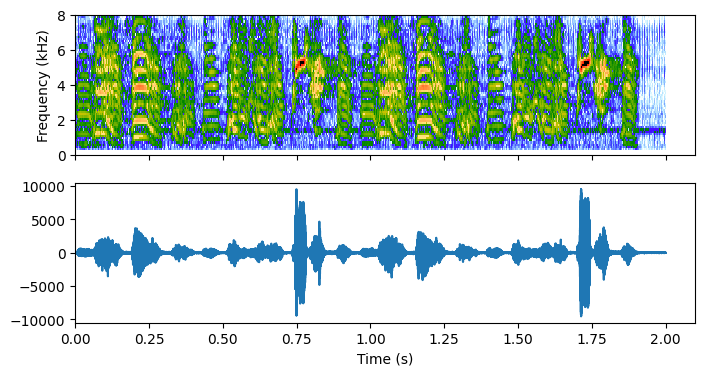

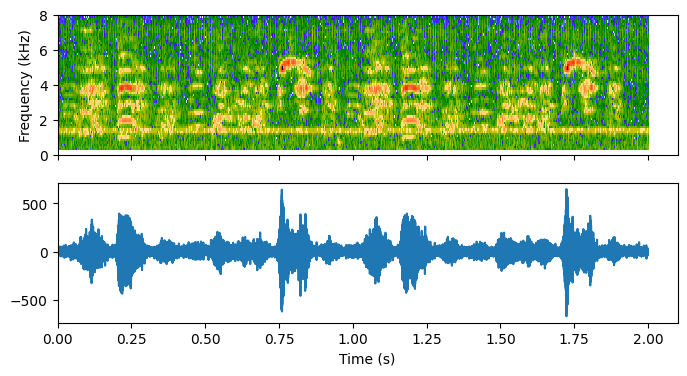

In [28]:
# Choose a ramdom trial
trial = trials.sample().iloc[0]
print(f"    the selected trial is : {trial['trial_num']}, {trial['experiment_uid']} ")
mic_trial, mic_copy = get_mic_data(nwb, trial)
rate = nwb.acquisition['audio'].rate
print(f"    mic_trial shape: {mic_trial.shape}, mic_copy shape: {mic_copy.shape}, rate: {rate}")

# Spectrogram paramteters.
stim_params = {}
stim_params['fband'] = 120
stim_params['nstd'] = 6
stim_params['high_freq'] = 8000
stim_params['low_freq'] = 250
stim_params['log'] = 1
stim_params['stim_rate'] = 1000  # Sample rate of spectrogram
DBNOISE = 80
# Colormap for plotting spectrograms
spec_colormap()   # defined in sound.py


# First figure for the microphone copy
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, figsize = (8,4))

tfrep = timefreq_raw(mic_copy, rate, 'ft', params=stim_params)
cmap = plt.get_cmap('SpectroColorMap')

minSpect = tfrep['spec'].max()-DBNOISE
maxB = tfrep['spec'].max()
ax1.imshow(tfrep['spec'], extent=[tfrep['t'][0], tfrep['t'][-1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap=cmap, vmin=minSpect, vmax=maxB)
ax1.set_ylim(0, 8)
ax1.set_ylabel('Frequency (kHz)')

tval = np.arange(stop=len(mic_copy))/rate
ax2.plot(tval, mic_copy)
ax2.set_xlabel('Time (s)')

# Second copy for the microphone 
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=100, figsize = (8,4))

tfrep = timefreq_raw(mic_trial, rate, 'ft', params=stim_params)
minSpect = tfrep['spec'].max()-DBNOISE
maxB = tfrep['spec'].max()
ax1.imshow(tfrep['spec'], extent=[tfrep['t'][0], tfrep['t'][-1], tfrep['f'][0]*1e-3, tfrep['f'][-1]*1e-3],
                aspect='auto', interpolation='nearest', origin='lower', cmap=cmap, vmin=minSpect, vmax=maxB)
ax1.set_ylim(0, 8)
ax1.set_ylabel('Frequency (kHz)')

tval = np.arange(stop=len(mic_trial))/rate
ax2.plot(tval, mic_trial)
ax2.set_xlabel('Time (s)')

